In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv("C:\ML_work\Datasets\Customer_Churn\customer_churn_data.csv")

In [3]:
df.shape

(5880, 21)

In [4]:
pd.set_option('display.max_columns', None)
df.head(2)
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,No,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes


In [5]:
df.nunique()

customerID          5880
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      4439
TotalCharges        5794
Churn                  2
dtype: int64

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
def conv_binary(feature_name):
    if df[feature_name].nunique() >= 2 and df[feature_name].nunique() <= 5:
        print(f"Feature '{feature_name}' has values count is {df[feature_name].value_counts()}")
    return df
for i in df.columns:
    conv_binary(i)

Feature 'gender' has values count is gender
Male      2950
Female    2930
Name: count, dtype: int64
Feature 'SeniorCitizen' has values count is SeniorCitizen
1    2944
0    2936
Name: count, dtype: int64
Feature 'Partner' has values count is Partner
Yes    2995
No     2885
Name: count, dtype: int64
Feature 'Dependents' has values count is Dependents
No     3004
Yes    2876
Name: count, dtype: int64
Feature 'PhoneService' has values count is PhoneService
Yes    2941
No     2939
Name: count, dtype: int64
Feature 'MultipleLines' has values count is MultipleLines
No phone service    2939
Yes                 1512
No                  1429
Name: count, dtype: int64
Feature 'InternetService' has values count is InternetService
No             2029
DSL            1936
Fiber optic    1915
Name: count, dtype: int64
Feature 'OnlineSecurity' has values count is OnlineSecurity
No internet service    2029
No                     1947
Yes                    1904
Name: count, dtype: int64
Feature 'Online

In [8]:
pd.crosstab(
    df['DeviceProtection'],
    df['Churn'],
    normalize='index'
) * 100

Churn,No,Yes
DeviceProtection,,
No,51.948052,48.051948
No internet service,50.320355,49.679645
Yes,49.896158,50.103842


In [9]:
# columns_to_replace = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# for col in columns_to_replace:
#     df[col] = df[col].replace('No internet service', 'No')

# df.head(2)

In [10]:
def conv_binary(feature_name):
    if df[feature_name].nunique() ==2:
        df[feature_name] = df[feature_name].map(lambda x: 1 if x==df[feature_name].unique()[0] else 0)
    else:
        print(f"Feature '{feature_name}' is not binary and cannot be converted.")
    return df
for i in df.columns:
    conv_binary(i)

Feature 'customerID' is not binary and cannot be converted.
Feature 'tenure' is not binary and cannot be converted.
Feature 'MultipleLines' is not binary and cannot be converted.
Feature 'InternetService' is not binary and cannot be converted.
Feature 'OnlineSecurity' is not binary and cannot be converted.
Feature 'OnlineBackup' is not binary and cannot be converted.
Feature 'DeviceProtection' is not binary and cannot be converted.
Feature 'TechSupport' is not binary and cannot be converted.
Feature 'StreamingTV' is not binary and cannot be converted.
Feature 'StreamingMovies' is not binary and cannot be converted.
Feature 'Contract' is not binary and cannot be converted.
Feature 'PaymentMethod' is not binary and cannot be converted.
Feature 'MonthlyCharges' is not binary and cannot be converted.
Feature 'TotalCharges' is not binary and cannot be converted.


In [11]:
df.drop("customerID",axis=1,inplace=True)

In [12]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,1,1,1,23,1,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,1,Bank transfer,49.85,1146.55,1
1,0,1,0,0,43,1,No phone service,DSL,Yes,No,Yes,No,Yes,No,Month-to-month,0,Mailed check,100.70,4330.10,0
2,1,0,1,0,51,0,No,DSL,No,Yes,Yes,Yes,No,No,One year,0,Electronic check,97.33,4963.83,0


In [13]:
from sklearn.model_selection import train_test_split

y = df['Churn']
X = df.drop('Churn',axis=1)
X =  pd.get_dummies(X,dtype=int)
X = X.drop([
    'StreamingMovies_No internet service',
    'StreamingTV_No internet service',
    'TechSupport_No internet service',
    'DeviceProtection_No internet service',
    'OnlineBackup_No internet service',
    'OnlineSecurity_No internet service',
     'MultipleLines_No phone service'
], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,1,1,1,23,1,1,49.85,1146.55,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,0,1,0,0,43,1,0,100.70,4330.10,0,0,1,0,0,0,1,1,0,0,1,1,0,0,1,1,0,1,0,0,0,0,0,1


In [14]:
def conv_binary(feature_name):
    if df[feature_name].dtype == 'int64' or df[feature_name].dtype == 'float64':
        corr=df['Churn'].corr(df[feature_name])
        print(f"Feature '{feature_name}' has correlation with target variable is {corr}") 
    else:
        print(f"Feature '{feature_name}' has data type is {df[feature_name].dtype} and cannot be used for correlation.")
    return df
for i in df.columns:
    conv_binary(i)

Feature 'gender' has correlation with target variable is -0.008212741751608932
Feature 'SeniorCitizen' has correlation with target variable is -0.004742956805168731
Feature 'Partner' has correlation with target variable is 0.010134002742221865
Feature 'Dependents' has correlation with target variable is -0.0010499185922617147
Feature 'tenure' has correlation with target variable is -0.008599723357449133
Feature 'PhoneService' has correlation with target variable is -0.018024192137513783
Feature 'MultipleLines' has data type is object and cannot be used for correlation.
Feature 'InternetService' has data type is object and cannot be used for correlation.
Feature 'OnlineSecurity' has data type is object and cannot be used for correlation.
Feature 'OnlineBackup' has data type is object and cannot be used for correlation.
Feature 'DeviceProtection' has data type is object and cannot be used for correlation.
Feature 'TechSupport' has data type is object and cannot be used for correlation.
F

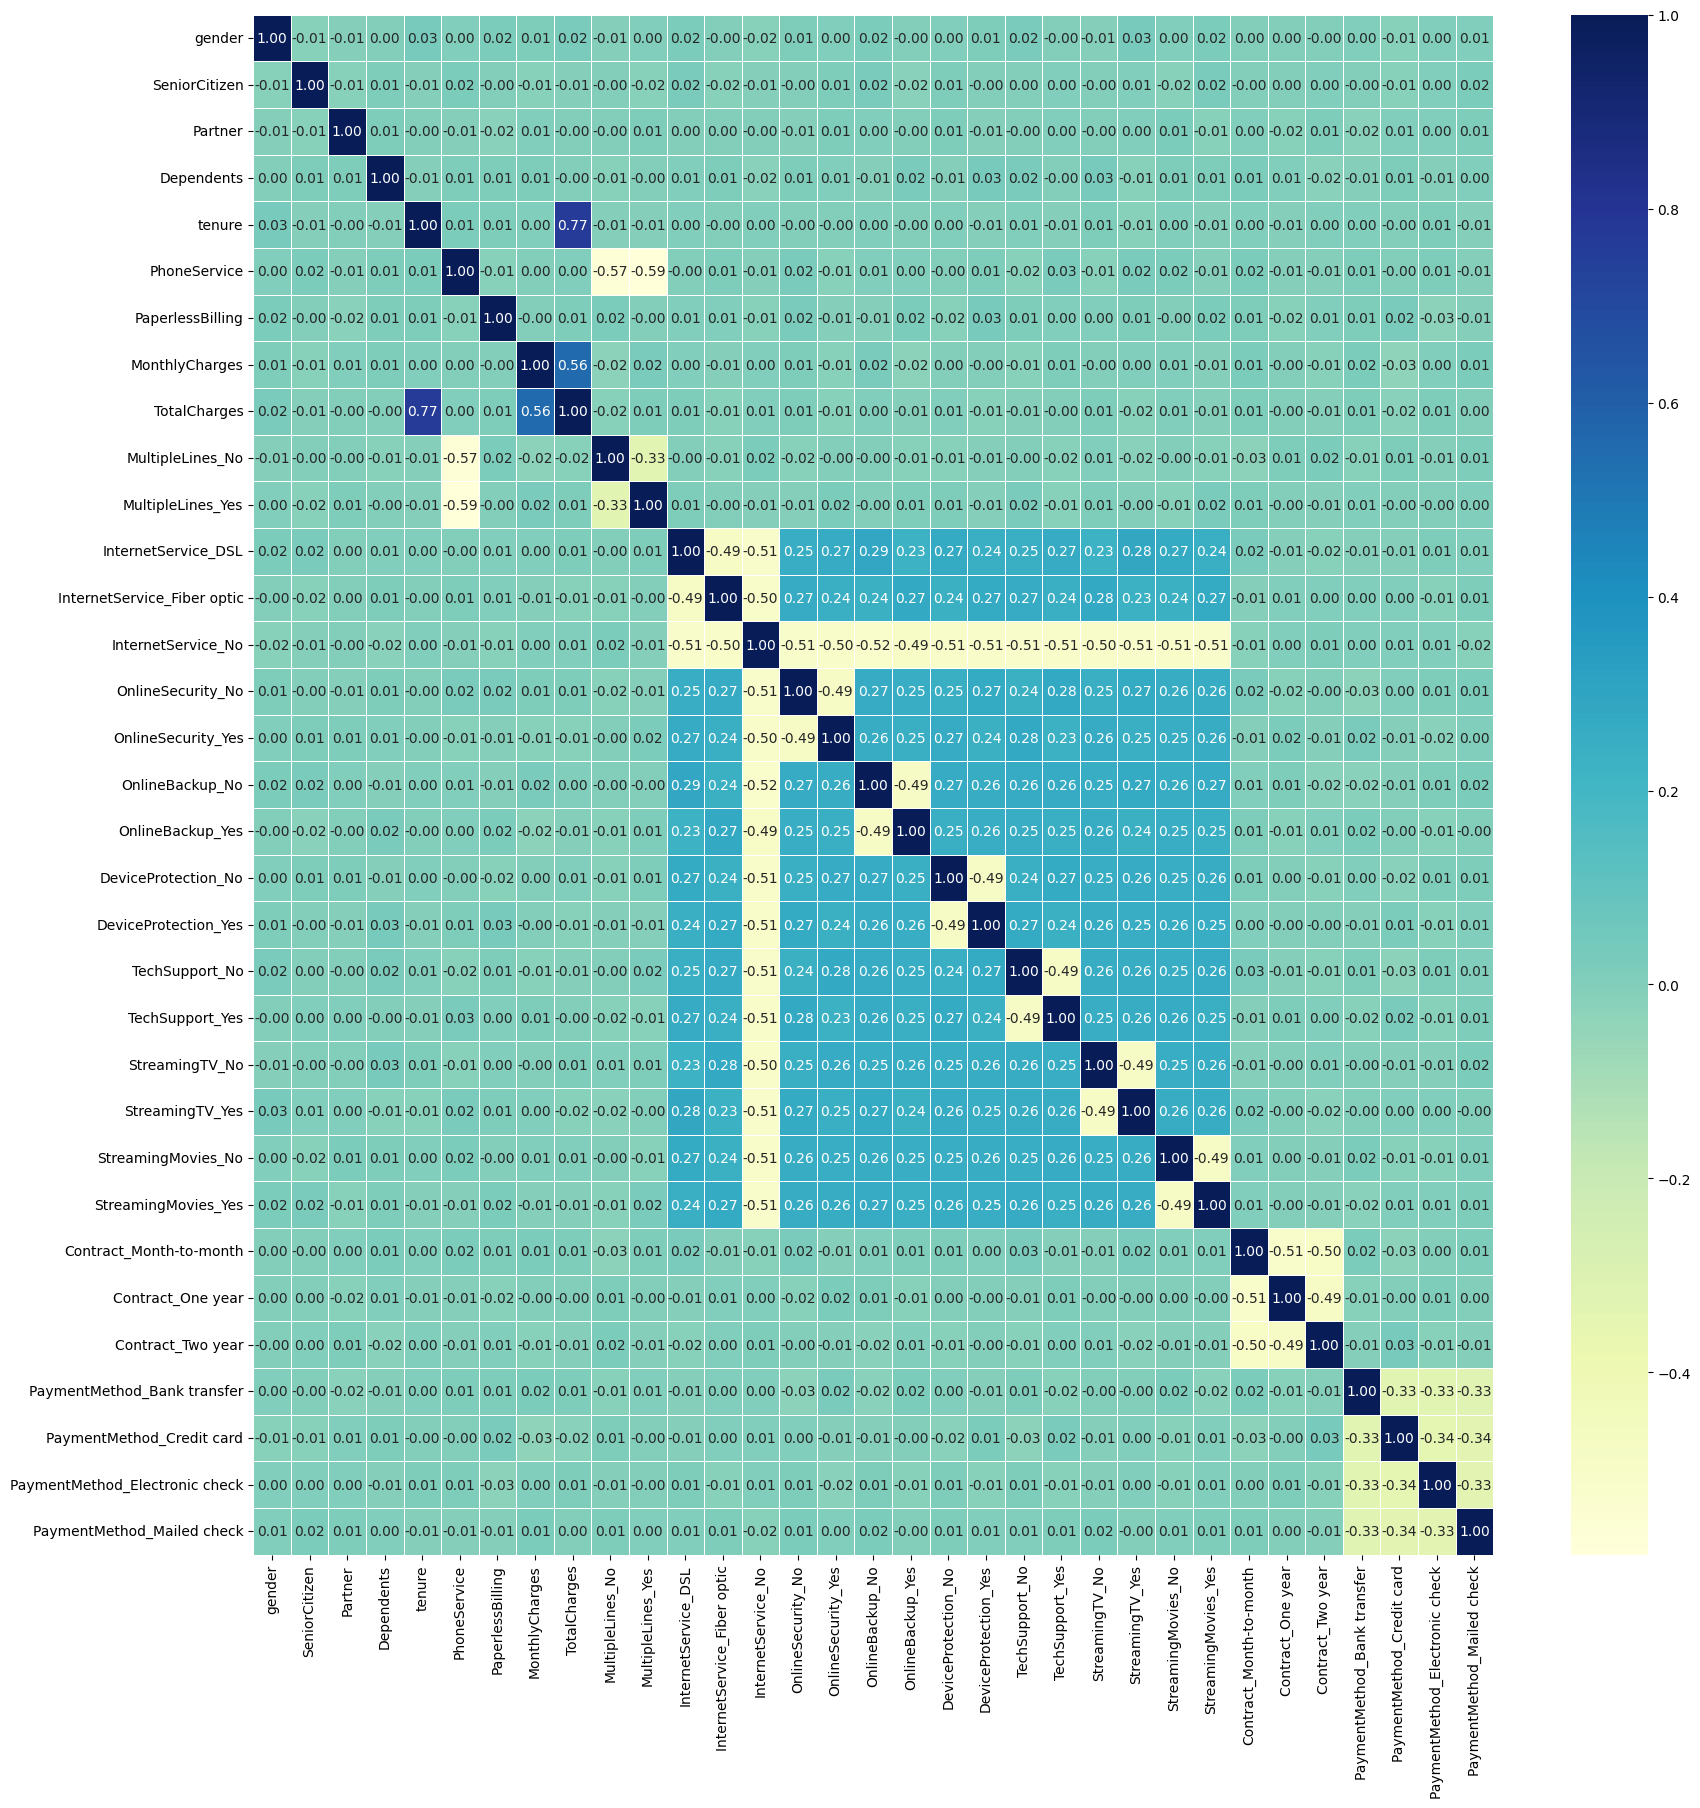

In [15]:
# Compute correlation matrix
co_mtx = X.corr(numeric_only=True)
plt.figure(figsize=(20,20))
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=.5)

# Display heatmap

plt.show()

In [24]:

model = XGBClassifier(n_estimators=10, learning_rate=0.01, max_depth=10)
model.fit(X_train, y_train)
# Make predictions and evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 50.43%


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, classifier in models.items():
    print(name)
    classifier.fit(X_train, y_train)

    predictions = classifier.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f"{name}: {accuracy*100:.2f}%")

Random Forest
Random Forest: 50.26%
XGBoost
XGBoost: 49.40%
Gradient Boosting
Gradient Boosting: 48.13%


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

param_grids = {

    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },

    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },

    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    }
}

In [ ]:
from sklearn.model_selection import GridSearchCV

for name, model in models.items():

    print(f"\n{name}")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Best Parameters:")
    print(grid.best_params_)

    print("Best CV Score:")
    print(grid.best_score_)


Random Forest
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score:
0.5087154905374545

XGBoost
Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score:
0.5214694643543537

Gradient Boosting
